# Explorando el Corazón de las Imágenes: VLAD vs. Fisher Vectors

¡Bienvenido a esta expedición al núcleo de la visión por computadora! Nuestra misión es responder una pregunta clave: entre dos de las técnicas más poderosas para "resumir" imágenes, **VLAD** y **Fisher Vector (FV)**, ¿cuál se lleva la corona?

Imagina que tienes que describir una foto compleja con unas pocas palabras. VLAD y FV son dos formas de hacer precisamente eso, pero para una computadora. Toman toda la riqueza visual de una imagen y la condensan en un único y potente "ADN" numérico: un vector de características.

A lo largo de este proyecto, nuestro viaje seguirá estos pasos:
1.  **Preparar el Terreno:** Cargaremos el famoso dataset CIFAR-10, nuestro campo de pruebas.
2.  **Extraer la Esencia:** Usaremos una red neuronal pre-entrenada (VGG16), como si fuera un "experto en arte", para descomponer cada imagen en sus "ingredientes" visuales básicos (descriptores locales).
3.  **Construir los Resúmenes:** Implementaremos tanto VLAD como FV para crear los vectores que representan a cada imagen.
4.  **El Veredicto Final:** Entrenaremos un clasificador para cada tipo de vector y mediremos su precisión para ver cuál de los dos métodos fue mejor capturando la identidad de las imágenes.

¡Empecemos!

In [1]:
# --- Paso 0: Importando Nuestras Herramientas ---
# Agrupamos todas nuestras importaciones aquí para tener un taller limpio y ordenado.

# Para manipulación de datos y computación numérica
import numpy as np
import pandas as pd

# Para el manejo de redes neuronales y datasets de imágenes
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Para Machine Learning clásico (PCA, K-Means, GMM, SVM)
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import normalize
from sklearn.metrics import pairwise_distances_argmin_min, accuracy_score, classification_report

# Para visualizar nuestros resultados
import matplotlib.pyplot as plt

# Utilidades del sistema y otros
import time
import os
import gc  # Garbage Collector, para limpiar la memoria
import joblib # Para guardar nuestros modelos entrenados
from tqdm.notebook import tqdm # ¡Para barras de progreso amigables!

print("¡Todas las herramientas han sido importadas y están listas para usarse!")

¡Todas las herramientas han sido importadas y están listas para usarse!


# Paso 1: Nuestro Campo de Juego - El Dataset CIFAR-10

### ¿Qué es CIFAR-10?

Piensa en **CIFAR-10** como una baraja de cartas de aprendizaje para una inteligencia artificial. Es uno de los conjuntos de datos más clásicos en visión por computadora, perfecto para poner a prueba nuevas ideas.

*   **Contenido:** 60,000 pequeñas imágenes a color (32x32 píxeles).
*   **Clases:** Las imágenes se dividen en 10 categorías: `avión`, `coche`, `pájaro`, `gato`, `ciervo`, `perro`, `rana`, `caballo`, `barco` y `camión`.
*   **División:** Se separa en un mazo de **entrenamiento** (50,000 imágenes para aprender) y uno de **prueba** (10,000 para evaluar qué tan bien hemos aprendido).

### ¿Por qué lo usamos?

CIFAR-10 es la materia prima para nuestro experimento. Lo usaremos para todo el proceso:
1.  **Extracción de Pistas Visuales:** De cada imagen, extraeremos "pistas" o descriptores. Imagina que en una foto de un gato, una pista podría ser la punta de una oreja, otra la textura del pelaje, etc.
2.  **Agregación (El Corazón del Proyecto):** Aquí es donde **VLAD** y **Fisher Vector** toman el montón de "pistas" de una imagen y lo resumen en un **único vector numérico**.
3.  **Aprendizaje y Clasificación:** Alimentaremos estos vectores resumen a un clasificador (SVM). El clasificador aprenderá a asociar un vector específico con su etiqueta correcta (ej: "este tipo de vector suele ser un gato").
4.  **La Prueba Final:** Usaremos las 10,000 imágenes que el modelo nunca ha visto para medir su precisión. Esto nos dirá, de forma objetiva, qué método fue mejor.

¡Éxito! Tenemos 10000 imágenes para entrenar.
Y 2000 imágenes para poner a prueba nuestro modelo.

Un pequeño vistazo a nuestros datos:


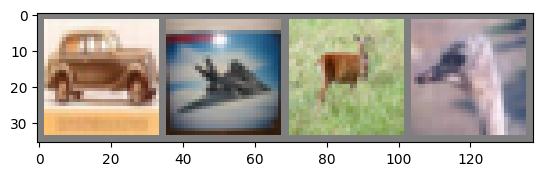

car   plane deer  bird 


In [2]:
# --- Carga y Preparación de CIFAR-10 ---

# 1. Definimos la "receta" de pre-procesamiento.
transform = transforms.Compose([
    transforms.ToTensor(), # Convertir la imagen a un tensor numérico.
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalizar los píxeles.
])

# 2. Descargamos y preparamos los conjuntos de datos.
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
full_testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# --- Reducción del Dataset para evitar problemas de memoria ---
train_indices = torch.randperm(len(full_trainset))[:10000]
test_indices = torch.randperm(len(full_testset))[:2000]
trainset = torch.utils.data.Subset(full_trainset, train_indices)
testset = torch.utils.data.Subset(full_testset, test_indices)

# 3. Creamos los "DataLoaders", cintas transportadoras que nos dan las imágenes en lotes.
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

print(f"¡Éxito! Tenemos {len(trainset)} imágenes para entrenar.")
print(f"Y {len(testset)} imágenes para poner a prueba nuestro modelo.")

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# --- Verificación Visual ---
def imshow(img):
    img = img / 2 + 0.5     # Deshacemos la normalización para poder verla.
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

print("\nUn pequeño vistazo a nuestros datos:")
imshow(torchvision.utils.make_grid(images[:4]))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

# Paso 2: Extrayendo la Esencia de las Imágenes

Las imágenes, para una computadora, son solo números. Necesitamos una forma más inteligente de representarlas. Aquí entra la **extracción de características**.

### ¿Qué son los "Descriptores Locales"?

En lugar de mirar la imagen completa, nos enfocaremos en extraer pequeños "fragmentos" de información visual, o **descriptores locales**. Piensa en ellos como las piezas de un rompecabezas: uno puede ser la textura de la hierba, otro el borde de una ventana, otro el ojo de un pájaro. Juntos, nos ayudarán a entender la imagen completa.

### Nuestra Herramienta: VGG16, un "Experto Visual" Pre-entrenado

Para encontrar estas piezas, usaremos un modelo muy poderoso llamado **VGG16**. Es una red neuronal que ya ha sido entrenada en millones de imágenes (del dataset ImageNet), convirtiéndose en una experta en reconocer patrones visuales.

Lo que haremos será:
1.  **Cargar a nuestro experto (VGG16)**.
2.  **"Cortar" sus últimas capas:** No nos interesa su clasificación final (que es para otras 1000 categorías), sino sus capas intermedias, donde reside su conocimiento sobre patrones visuales.
3.  **Pasar nuestras imágenes a través de él:** La salida será un conjunto de descriptores locales para cada imagen.

In [3]:
# --- 1. Configuración de VGG16 ---
vgg16 = models.vgg16(weights=models.VGG16_Weights.DEFAULT).eval()
feature_extractor = vgg16.features[:29]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

print(f"Usando el dispositivo: {device}")
print("¡Extractor de características (VGG16) listo!")

# --- 2. DataLoaders para Extracción ---
train_feature_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=False)
test_feature_loader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

# --- 3. Función de Extracción con Barra de Progreso ---
def extract_features(loader, extractor, device):
    all_descriptors = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extrayendo características"):
            images = images.to(device)
            features = extractor(images)
            B, C, H, W = features.shape
            descriptors = features.view(B, C, H * W).permute(0, 2, 1).reshape(-1, C)
            all_descriptors.append(descriptors.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_descriptors), np.concatenate(all_labels)

# --- 4. Ejecutamos la Extracción ---
print("\nIniciando extracción para el conjunto de ENTRENAMIENTO...")
start_time = time.time()
all_descriptors_train, train_labels = extract_features(train_feature_loader, feature_extractor, device)
print(f"...Completada en {time.time() - start_time:.2f} segundos.")
print(f"  -> Forma de descriptores: {all_descriptors_train.shape}")

print("Iniciando extracción para el conjunto de PRUEBA...")
start_time = time.time()
all_descriptors_test, test_labels = extract_features(test_feature_loader, feature_extractor, device)
print(f"...Completada en {time.time() - start_time:.2f} segundos.")
print(f"  -> Forma de descriptores: {all_descriptors_test.shape}")

Usando el dispositivo: cpu
¡Extractor de características (VGG16) listo!

Iniciando extracción para el conjunto de ENTRENAMIENTO...


Extrayendo características:   0%|          | 0/79 [00:00<?, ?it/s]

...Completada en 38.24 segundos.
  -> Forma de descriptores: (40000, 512)
Iniciando extracción para el conjunto de PRUEBA...


Extrayendo características:   0%|          | 0/16 [00:00<?, ?it/s]

...Completada en 7.86 segundos.
  -> Forma de descriptores: (8000, 512)


# Paso 3: Agregando las Piezas con VLAD

Ahora que tenemos una montaña de descriptores locales (nuestras "piezas de rompecabezas"), necesitamos ensamblarlos. Nuestro primer método es **VLAD (Vector of Locally Aggregated Descriptors)**.

### La Estrategia de VLAD
1.  **Crear un "Diccionario Visual" (Codebook):** Usamos K-Means para agrupar nuestros 200,000 descriptores en `k` clusters. El centro de cada cluster será una "palabra" en nuestro diccionario visual.
2.  **Calcular las Diferencias (Residuos):** Para cada descriptor de una imagen, encontramos la "palabra" más cercana en el diccionario y calculamos la diferencia (el "residuo").
3.  **Sumar y Concatenar:** Para cada palabra del diccionario, sumamos todos los residuos de los descriptores que se le asignaron. Al concatenar estas sumas, obtenemos nuestro vector VLAD final.

### 💡 Táctica Clave: PCA para Controlar la Memoria

Un vector VLAD puede ser gigantesco (`64 palabras * 512 dimensiones = 32,768`). Para evitar colapsar la memoria, primero usaremos **PCA (Análisis de Componentes Principales)** para comprimir inteligentemente nuestros descriptores de 512 a 128 dimensiones. Esto mantiene los vectores VLAD en un tamaño manejable (`64 * 128 = 8,192`).

In [4]:
# --- VLAD: Paso 1 - Compresión con PCA ---
print("--- Comprimiendo Descriptores con PCA ---")
pca_desc = PCA(n_components=128, svd_solver='randomized', random_state=42)
pca_desc.fit(all_descriptors_train)
desc_train_pca = pca_desc.transform(all_descriptors_train)
desc_test_pca = pca_desc.transform(all_descriptors_test)
print(f"¡Compresión lista! Nueva dimensión de descriptores: {desc_train_pca.shape[1]}")

# --- VLAD: Paso 2 - Creando el Diccionario Visual con K-Means ---
print("--- Creando el diccionario visual con K-Means ---")
k = 64
kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10)
kmeans.fit(desc_train_pca)
codebook = kmeans.cluster_centers_
print(f"Diccionario (codebook) creado. Forma: {codebook.shape}")

# --- VLAD: Paso 3 - Construyendo los Vectores Resumen ---
print("--- Construyendo los vectores VLAD ---")
n_images_train, n_images_test = len(train_labels), len(test_labels)
n_desc_per_img = 4
D_pca, K = codebook.shape[1], codebook.shape[0]

desc_train_per_img_pca = desc_train_pca.reshape(n_images_train, n_desc_per_img, D_pca)
desc_test_per_img_pca = desc_test_pca.reshape(n_images_test, n_desc_per_img, D_pca)

def compute_vlad_batch(descriptors_batch, codebook):
    vlad_vectors = np.zeros((descriptors_batch.shape[0], K * D_pca), dtype=np.float32)
    for i in tqdm(range(descriptors_batch.shape[0]), desc="Calculando VLAD"):
        cluster_indices, _ = pairwise_distances_argmin_min(descriptors_batch[i], codebook)
        vlad_vector = np.zeros((K, D_pca), dtype=np.float32)
        for j in range(n_desc_per_img):
            cluster_idx = cluster_indices[j]
            vlad_vector[cluster_idx] += (descriptors_batch[i][j] - codebook[cluster_idx])
        vlad_vectors[i] = vlad_vector.flatten()
    return vlad_vectors

vlad_train = compute_vlad_batch(desc_train_per_img_pca, codebook)
vlad_test = compute_vlad_batch(desc_test_per_img_pca, codebook)

print(f"¡Vectores VLAD generados! Forma (entrenamiento): {vlad_train.shape}")

# --- VLAD: Paso 4 - Normalización Final ---
print("--- Normalizando vectores VLAD (Power + L2) ---")
vlad_train_power = np.sign(vlad_train) * np.sqrt(np.abs(vlad_train))
vlad_test_power = np.sign(vlad_test) * np.sqrt(np.abs(vlad_test))
vlad_train_final = normalize(vlad_train_power, norm='l2', axis=1)
vlad_test_final = normalize(vlad_test_power, norm='l2', axis=1)
print("¡Normalización VLAD completada!")

--- Comprimiendo Descriptores con PCA ---


¡Compresión lista! Nueva dimensión de descriptores: 128
--- Creando el diccionario visual con K-Means ---


Diccionario (codebook) creado. Forma: (64, 128)
--- Construyendo los vectores VLAD ---


Calculando VLAD:   0%|          | 0/10000 [00:00<?, ?it/s]

Calculando VLAD:   0%|          | 0/2000 [00:00<?, ?it/s]

¡Vectores VLAD generados! Forma (entrenamiento): (10000, 8192)
--- Normalizando vectores VLAD (Power + L2) ---


¡Normalización VLAD completada!


# Paso 4: La Hora de la Verdad (Parte 1) - Clasificación con VLAD

In [5]:
print("--- Entrenando el clasificador para VLAD ---")
clf_vlad = LinearSVC(C=1.0, random_state=42, max_iter=2000)

start_time = time.time()
clf_vlad.fit(vlad_train_final, train_labels)
print(f"...Entrenamiento completado en {time.time() - start_time:.2f} segundos.")

preds_vlad = clf_vlad.predict(vlad_test_final)
acc_vlad = accuracy_score(test_labels, preds_vlad)

print("\n--- 🎯 Resultados de VLAD ---")
print(f"Precisión (Accuracy) obtenida con VLAD: {acc_vlad * 100:.2f}%")

# Guardamos el resultado para la comparación final
joblib.dump(clf_vlad, 'svm_vlad_classifier.joblib')
np.save('acc_vlad.npy', acc_vlad)

--- Entrenando el clasificador para VLAD ---


...Entrenamiento completado en 16.54 segundos.

--- 🎯 Resultados de VLAD ---
Precisión (Accuracy) obtenida con VLAD: 61.25%


In [6]:
print("--- Limpieza de Memoria Post-VLAD ---")
del vlad_train, vlad_train_power, vlad_train_final, vlad_test, vlad_test_power, vlad_test_final, clf_vlad
gc.collect()
print("Memoria de VLAD liberada. ¡Listos para Fisher Vector!")

--- Limpieza de Memoria Post-VLAD ---
Memoria de VLAD liberada. ¡Listos para Fisher Vector!


# Paso 5: Un Enfoque Más Sofisticado con Fisher Vector

Ahora, es el turno del "primo" más avanzado de VLAD: el **Fisher Vector (FV)**.

### La Filosofía de Fisher Vector

Mientras que VLAD asigna cada descriptor a la "palabra visual" más cercana, Fisher Vector es más sutil. Pregunta: "¿Cómo influye este descriptor en *todas* las palabras de nuestro diccionario a la vez?"

Para esto, necesita un diccionario más rico: un **Gaussian Mixture Model (GMM)**. Un GMM no solo encuentra centros (como K-Means), sino que modela los descriptores como una mezcla de varias "nubes" de puntos con forma de elipse (Gaussianas), dándonos una comprensión mucho más profunda de la estructura de nuestros datos.

In [7]:
# --- Fisher Vector: Paso 1 - Creando el Mapa Estadístico GMM ---
print("--- Entrenando el Gaussian Mixture Model (GMM) ---")
k_gmm = 64
gmm = GaussianMixture(n_components=k_gmm, covariance_type='diag', random_state=42, reg_covar=1e-6, verbose=1, max_iter=200)

start_time = time.time()
gmm.fit(desc_train_pca)
print(f"\n--- GMM creado en {time.time() - start_time:.2f} segundos. Convergió: {gmm.converged_} ---")

# --- Fisher Vector: Paso 2 - Construyendo los Vectores Resumen ---
print("--- Construyendo los Fisher Vectors ---")
weights, means, covs = gmm.weights_, gmm.means_, gmm.covariances_
sigmas = np.sqrt(covs)
fv_dim = 2 * k_gmm * D_pca

def compute_fv_batch(descriptors_batch, gmm):
    probs_batch = gmm.predict_proba(descriptors_batch.reshape(-1, D_pca))
    probs_batch_img = probs_batch.reshape(descriptors_batch.shape[0], n_desc_per_img, k_gmm)
    fv_vectors = np.zeros((descriptors_batch.shape[0], fv_dim), dtype=np.float32)
    
    for i in tqdm(range(descriptors_batch.shape[0]), desc="Calculando Fisher Vector"):
        grad_means = np.zeros((k_gmm, D_pca), dtype=np.float32)
        grad_sigmas = np.zeros((k_gmm, D_pca), dtype=np.float32)
        for t in range(n_desc_per_img):
            xt = descriptors_batch[i, t]
            gamma_t = probs_batch_img[i, t]
            diff = (xt - means) / sigmas
            grad_means += gamma_t[:, np.newaxis] * diff
            grad_sigmas += gamma_t[:, np.newaxis] * (diff**2 - 1)
        fv_vectors[i] = np.concatenate([(grad_means / (n_desc_per_img * np.sqrt(weights)[:, np.newaxis])).flatten(), 
                                      (grad_sigmas / (n_desc_per_img * np.sqrt(2 * weights)[:, np.newaxis])).flatten()])
    return fv_vectors

fv_train = compute_fv_batch(desc_train_per_img_pca, gmm)
fv_test = compute_fv_batch(desc_test_per_img_pca, gmm)
print(f"¡Fisher Vectors generados! Forma (entrenamiento): {fv_train.shape}")

# --- Fisher Vector: Paso 3 - Normalización Final ---
print("--- Normalizando Fisher Vectors (Power + L2) ---")
fv_train_power = np.sign(fv_train) * np.sqrt(np.abs(fv_train))
fv_test_power = np.sign(fv_test) * np.sqrt(np.abs(fv_test))
fv_train_final = normalize(fv_train_power, norm='l2', axis=1)
fv_test_final = normalize(fv_test_power, norm='l2', axis=1)
print("¡Normalización FV completada!")

--- Entrenando el Gaussian Mixture Model (GMM) ---
Initialization 0


  Iteration 10


  Iteration 20


  Iteration 30


  Iteration 40


...

Initialization converged.

--- GMM creado en 10.96 segundos. Convergió: True ---
--- Construyendo los Fisher Vectors ---


Calculando Fisher Vector:   0%|          | 0/10000 [00:00<?, ?it/s]

Calculando Fisher Vector:   0%|          | 0/2000 [00:00<?, ?it/s]

¡Fisher Vectors generados! Forma (entrenamiento): (10000, 16384)
--- Normalizando Fisher Vectors (Power + L2) ---


¡Normalización FV completada!


# Paso 6: La Hora de la Verdad (Parte 2) - Clasificación con Fisher Vector

In [8]:
print("--- Entrenando el clasificador para Fisher Vector ---")
clf_fv = SGDClassifier(loss='hinge', random_state=42, max_iter=2000, tol=1e-3)

start_time = time.time()
clf_fv.fit(fv_train_final, train_labels)
print(f"...Entrenamiento completado en {time.time() - start_time:.2f} segundos.")

preds_fv = clf_fv.predict(fv_test_final)
acc_fv = accuracy_score(test_labels, preds_fv)

print("\n--- 🎯 Resultados de Fisher Vector ---")
print(f"Precisión (Accuracy) obtenida con Fisher Vector: {acc_fv * 100:.2f}%")

joblib.dump(clf_fv, 'svm_fv_classifier.joblib')
np.save('acc_fv.npy', acc_fv)

--- Entrenando el clasificador para Fisher Vector ---


...Entrenamiento completado en 58.55 segundos.

--- 🎯 Resultados de Fisher Vector ---
Precisión (Accuracy) obtenida con Fisher Vector: 63.50%


# Paso 7: El Veredicto Final - VLAD vs. Fisher Vector

Hemos recorrido un largo camino. Implementamos dos métodos potentes para representar imágenes, los entrenamos en miles de ellas y ahora es el momento de la verdad.

En esta celda final, cargaremos los resultados de precisión de ambos modelos y los presentaremos en una tabla y un gráfico comparativo para declarar un ganador.

--- Evaluación Final: VLAD vs. Fisher Vector (FV) ---
Score de VLAD cargado: 61.25%
Score de Fisher Vector cargado: 63.50%

--- Tabla Comparativa de Resultados ---
            Método  Precisión (%)  Dimensiones del Vector
              VLAD          61.25                    8192
Fisher Vector (FV)          63.50                   16384

🏆 Conclusión: Fisher Vector (FV) es el ganador con una precisión superior.



¡Gráfico de comparación guardado como 'comparacion_vlad_vs_fv.png'!


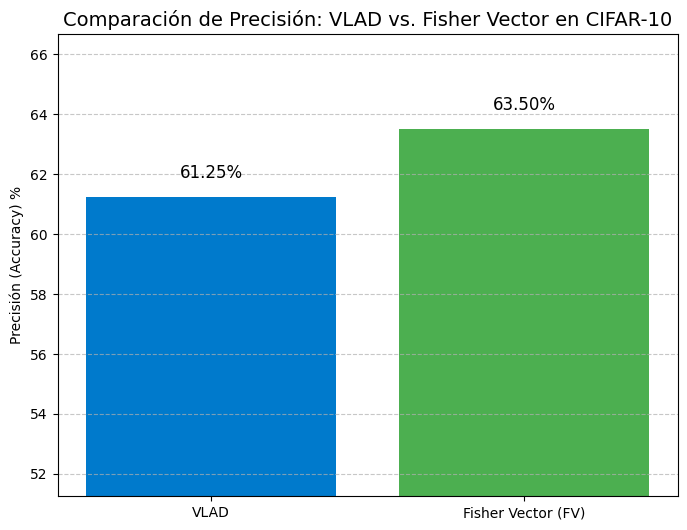

In [9]:
print("--- Evaluación Final: VLAD vs. Fisher Vector (FV) ---")

# --- 1. Carga de Resultados ---
try:
    acc_vlad_loaded = np.load('acc_vlad.npy')
    acc_fv_loaded = np.load('acc_fv.npy')
    print(f"Score de VLAD cargado: {acc_vlad_loaded*100:.2f}%")
    print(f"Score de Fisher Vector cargado: {acc_fv_loaded*100:.2f}%")

    # --- 2. Comparación y Visualización ---
    results = {
        'Método': ['VLAD', 'Fisher Vector (FV)'],
        'Precisión (%)': [round(acc_vlad_loaded * 100, 2), round(acc_fv_loaded * 100, 2)],
        'Dimensiones del Vector': [8192, 16384]
    }
    df_results = pd.DataFrame(results)

    print("\n--- Tabla Comparativa de Resultados ---")
    print(df_results.to_string(index=False))

    if acc_fv_loaded > acc_vlad_loaded:
        print(f"\n🏆 Conclusión: Fisher Vector (FV) es el ganador con una precisión superior.")
    else:
        print(f"\n🏆 Conclusión: VLAD es el ganador con una precisión superior.")
        
    # --- Gráfico de Barras ---
    plt.figure(figsize=(8, 6))
    bars = plt.bar(df_results['Método'], df_results['Precisión (%)'], color=['#007ACC', '#4CAF50'])
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{yval:.2f}%', va='bottom', ha='center', fontsize=12)
    plt.ylabel('Precisión (Accuracy) %')
    plt.title('Comparación de Precisión: VLAD vs. Fisher Vector en CIFAR-10', fontsize=14)
    plt.ylim(bottom=max(0, df_results['Precisión (%)'].min() - 10))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig('comparacion_vlad_vs_fv.png')
    print("\n¡Gráfico de comparación guardado como 'comparacion_vlad_vs_fv.png'!")
    plt.show()
except FileNotFoundError:
    print("ADVERTENCIA: No se encontraron los archivos de resultados ('acc_vlad.npy', 'acc_fv.npy').")
    print("Por favor, asegúrate de ejecutar todo el cuaderno para generar estos archivos.")